Attempting decompositions:   0%|          | 0/128 [00:00<?, ?it/s]

Attempting decompositions: 100%|██████████| 128/128 [01:41<00:00,  1.26it/s]

Approximate Haar volume covered: 1.0


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

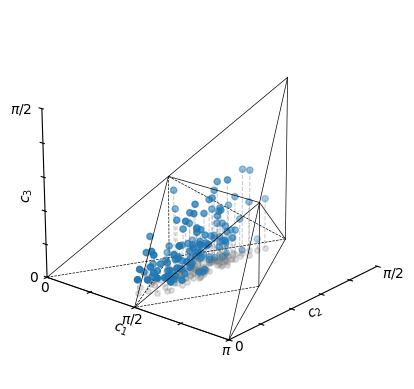

In [11]:
from gulps.core.coverage import weyl_linspace
from tqdm import tqdm
from gulps.viz.invariant_viz import scatter_plot
from qiskit.circuit.library import RVGate, iSwapGate
from scipy.optimize import minimize
from gulps.core import GateInvariants
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit import ParameterVector
from qiskit.quantum_info.random import random_unitary

N = 2**7
sentence_length = 3

random_restarts = 3
convergence_threshold = 1e-4


def ansatz():
    num_params = 6 * sentence_length
    p = ParameterVector("p", num_params)
    qc = QuantumCircuit(2)
    for i in range(sentence_length - 1):
        qc.append(iSwapGate().power(0.5), [0, 1])
        qc.append(RVGate(p[0 + 6 * i], p[1 + 6 * i], p[2 + 6 * i]), [0])
        qc.append(RVGate(p[3 + 6 * i], p[4 + 6 * i], p[5 + 6 * i]), [1])
    qc.append(iSwapGate().power(0.5), [0, 1])
    return qc, num_params


ansatz_qc, num_params = ansatz()


def bind_ansatz(p):
    bound_qc = ansatz_qc.assign_parameters(
        {param: val for param, val in zip(ansatz_qc.parameters, p)}
    )
    return GateInvariants.from_unitary(Operator(bound_qc))


# NOTE, linspace is deliberately NOT uniform (Haar measure) to get better "corner" finding
use_haar = True


def domain_generator(N):
    if use_haar:
        return (GateInvariants.from_unitary(random_unitary(4)) for _ in range(N))
    return (GateInvariants.from_weyl(c) for c in weyl_linspace(N))


inv_list = []
for target_gate in tqdm(domain_generator(N), total=N, desc="Attempting decompositions"):

    def makhlin_objective(p):
        U = bind_ansatz(p)
        return np.linalg.norm(np.array(U.makhlin) - np.array(target_gate.makhlin)) ** 2

    for _ in range(random_restarts):
        attempt = minimize(
            makhlin_objective,
            x0=np.pi * np.random.rand(num_params) - np.pi / 2,
            method="Nelder-Mead",
        )
        if attempt.success and attempt.fun < 1e-4:
            inv_list.append(target_gate)
            break

if use_haar:
    print("Approximate Haar volume covered:", len(inv_list) / N)
scatter_plot(inv_list)

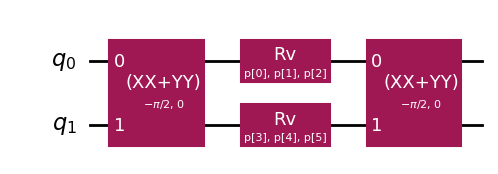

In [5]:
ansatz_qc.draw("mpl")